In [1]:
import os
os.environ['HF_HOME'] = '/media/anna/Samsung_T5/hf_cache'
os.environ['HF_HUB_CACHE'] = '/media/anna/Samsung_T5/hf_cache/hub'

from transformers import RobertaForMaskedLM
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import re

matplotlib.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

2026-04-21 22:24:56.061050: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def flatten_model(model, n_layers=12):
    """Extract and flatten encoder weight matrices by layer.
    Returns list of n_layers flattened arrays, excluding LayerNorm and biases.
    """
    params_by_layer = [[] for _ in range(n_layers)]
    for name, param in model.named_parameters():
        if 'encoder' not in name or not name.endswith('weight') or 'LayerNorm' in name:
            continue
        m = re.search(r'encoder\.layer\.(\d+)\.', name)
        if not m:
            continue
        layer_num = int(m.group(1))
        param_np = param.detach().numpy()
        if param_np.ndim > 1:
            params_by_layer[layer_num].extend(param_np)
        else:
            params_by_layer[layer_num].append(param_np)
    return [[i for p in layer for i in p] for layer in params_by_layer]


def flatten_all(flattened_layers):
    """Collapse all layers into a single array."""
    return [v for layer in flattened_layers for v in layer]


def make_hist(flat_weights, bins=100, log=True, filter_high=True, cutoff=0.6):
    """Compute histogram, returning (centers, counts) ready to plot."""
    weights = [w for w in flat_weights if abs(w) < cutoff] if filter_high else flat_weights
    counts, edges = np.histogram(weights, bins=bins)
    if log:
        counts = np.log10([c + 1 for c in counts])
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, counts

## Load models

| Variable | Path | Training config |
|---|---|---|
| `m_init` | Samsung T5 | Random initialisation (untrained) |
| `m_linear` | easystore | HF Trainer · linear LR decay · warmup 5k · grad clip 1.0 |
| `m_clr` | easystore | HF Trainer · constant LR · warmup 5k · grad clip 1.0 |
| `m_babylm` | Samsung T5 HPC store | BabyLM code · fixed LR · warmup 5k · grad clip 1.0 · distributed |
| `m_base` | HuggingFace | Public `roberta-base` (target distribution) |

In [3]:
print("Loading random init...")
m_init   = RobertaForMaskedLM.from_pretrained('/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_init')
print("Loading linear LR model...")
m_linear = RobertaForMaskedLM.from_pretrained('/media/anna/easystore/initialization_all_epochs/roberta_100M/final')
print("Loading constant LR model...")
m_clr    = RobertaForMaskedLM.from_pretrained('/media/anna/easystore/initialization_all_epochs/roberta_100M_clr/final')
print("Loading BabyLM code model...")
m_babylm = RobertaForMaskedLM.from_pretrained('/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_100M/hf_20')
print("Loading roberta-base...")
m_base   = RobertaForMaskedLM.from_pretrained('roberta-base')
print("Done.")

Loading random init...
Loading linear LR model...
Loading constant LR model...
Loading BabyLM code model...
Loading roberta-base...
Done.


In [5]:
m100 = RobertaForMaskedLM.from_pretrained("/media/anna/easystore/initialization_all_epochs/roberta_100M/epoch_20_0")

In [6]:
flat_init   = flatten_model(m_init)
flat_linear = flatten_model(m_linear)
flat_clr    = flatten_model(m_clr)
flat_babylm = flatten_model(m_babylm)



KeyboardInterrupt



In [14]:
flat_base   = flatten_model(m_base)

In [17]:
import numpy as np
print(np.std(flat_base))
print(np.mean(flat_base))

0.053069357
-0.0026645558


In [21]:
x = np.array(flat_base) > 0.1
np.sum(x)/x.size

0.027813275655110676

In [12]:
flat_m100 = flatten_model(m100)

## Figure 1: All models overlaid (all layers collapsed)

Main comparison figure. All encoder weights pooled across layers.

In [ ]:
MODELS = [
    (flat_init,   'Random init',                 '#aaaaaa', '--'),
    (flat_linear, 'Linear LR decay',             '#e07b39', '-'),
    (flat_clr,    'Constant LR',                 '#4c8be0', '-'),
    (flat_babylm, 'BabyLM training code',        '#2ca02c', '-'),
    (flat_base,   'RoBERTa-base (public)',        '#222222', '-'),
]

fig, ax = plt.subplots(figsize=(7, 4))

for flat_layers, label, color, ls in MODELS:
    centers, counts = make_hist(flatten_all(flat_layers), bins=120, log=True, filter_high=True)
    ax.plot(centers, counts, label=label, color=color, linestyle=ls, linewidth=1.5)

ax.set_xlabel('Weight value')
ax.set_ylabel('Log\u2081\u2080 count')
ax.set_title('Encoder weight distributions — 100M training, all layers')
ax.legend(framealpha=0.9)
ax.set_xlim(-0.6, 0.6)
fig.tight_layout()
fig.savefig('weight_dist_100M_overlay.pdf', format='pdf')
plt.show()
print('Saved weight_dist_100M_overlay.pdf')

## Figure 2: Per-layer comparison grid

One subplot per layer, all models overlaid. Useful for seeing whether distributional
differences are uniform across depth or concentrated in particular layers.

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
plt.subplots_adjust(hspace=0.35, wspace=0.25)
fig.suptitle('Encoder weight distributions by layer — 100M training', fontsize=14, y=1.01)

for layer_idx, ax in enumerate(axes.flat):
    for flat_layers, label, color, ls in MODELS:
        centers, counts = make_hist(flat_layers[layer_idx], bins=100, log=True, filter_high=True)
        ax.plot(centers, counts, label=label, color=color, linestyle=ls, linewidth=1.2)
    ax.set_title(f'Layer {layer_idx}')
    ax.set_xlim(-0.6, 0.6)
    ax.set_xlabel('Weight value', fontsize=9)
    ax.set_ylabel('Log\u2081\u2080 count', fontsize=9)
    ax.tick_params(labelsize=8)

# Single legend below the grid
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04),
           framealpha=0.9, fontsize=10)
fig.tight_layout()
fig.savefig('weight_dist_100M_by_layer.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved weight_dist_100M_by_layer.pdf')

## Figure 3: Individual per-model figures

Each model shown separately with one line per layer. Good for layer-level detail.

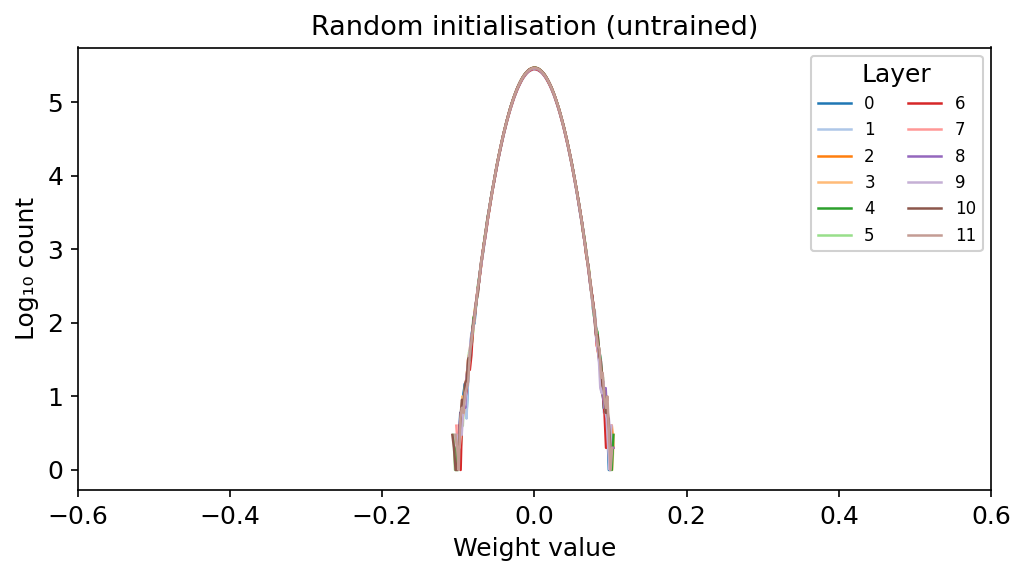

Saved weight_dist_init.pdf


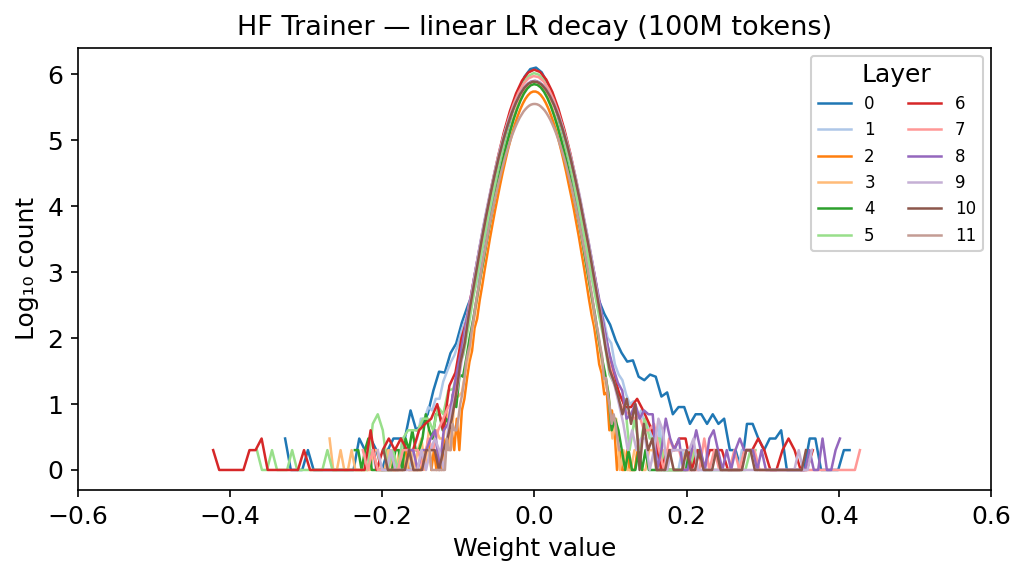

Saved weight_dist_100M_linear.pdf


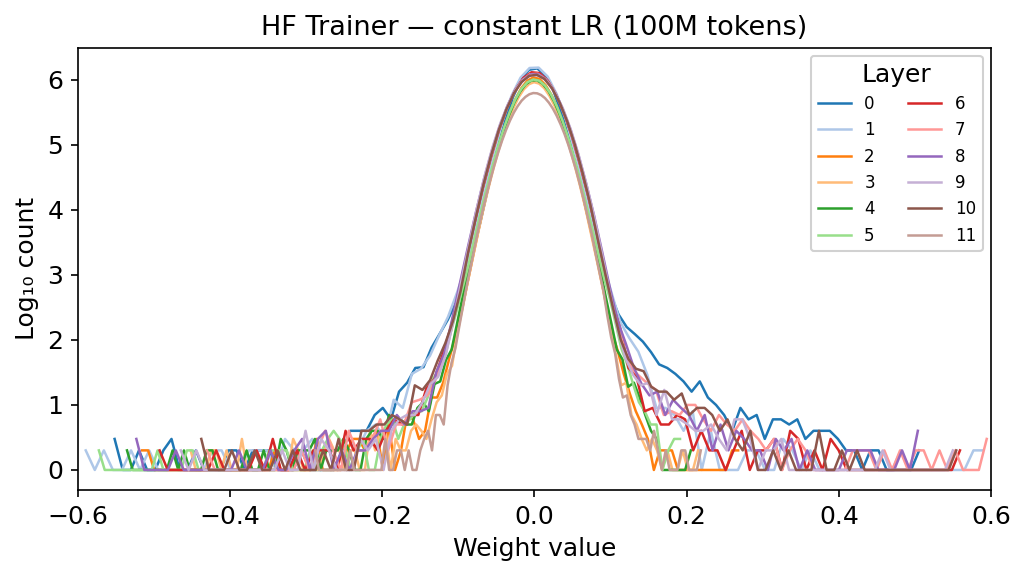

Saved weight_dist_100M_clr.pdf


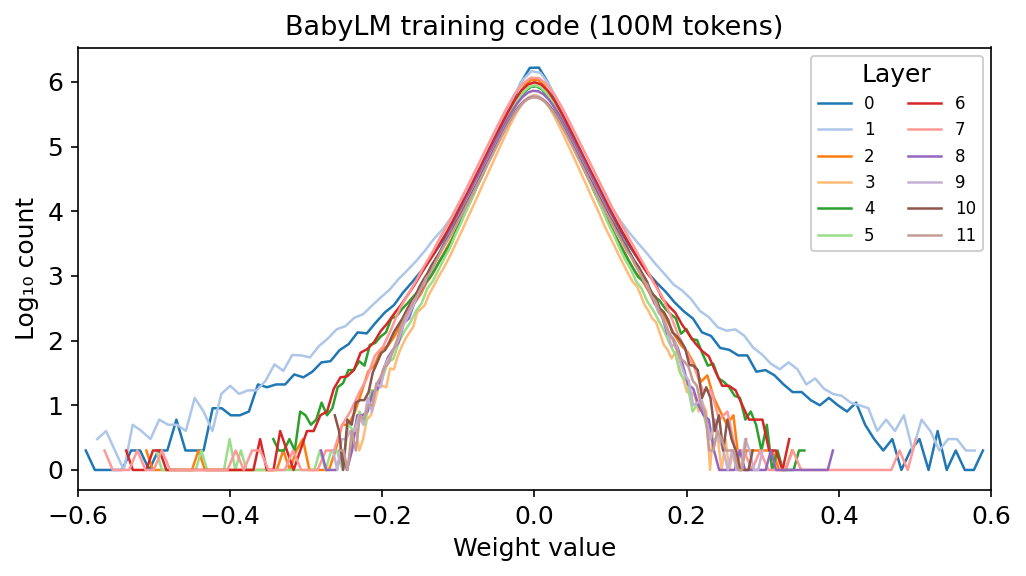

Saved weight_dist_100M_babylm.pdf


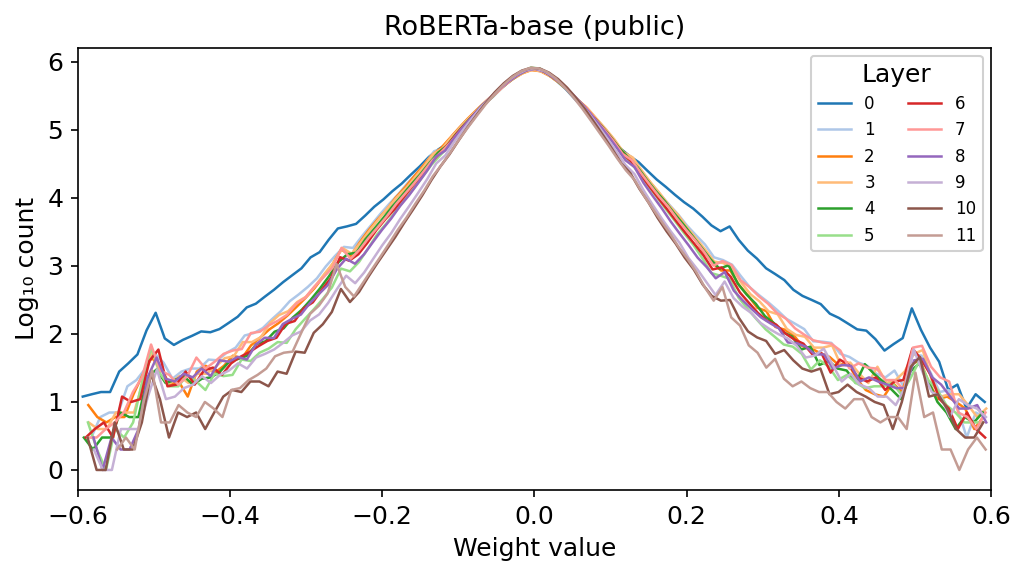

Saved weight_dist_roberta_base.pdf


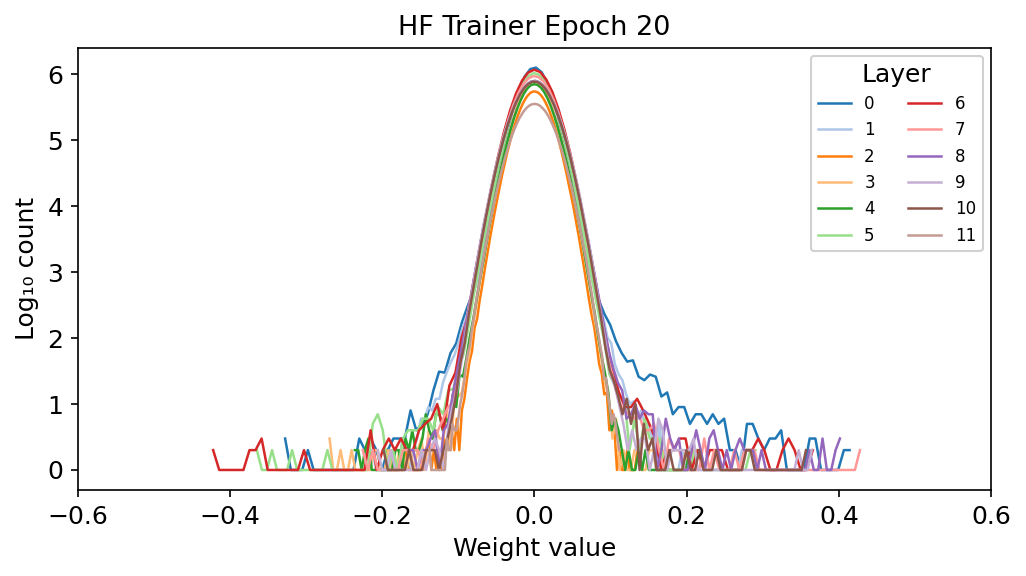

Saved weight_dist_100M_epoch20.pdf


In [15]:
MODEL_DETAILS = [
    (flat_init,   'Random initialisation (untrained)',          'weight_dist_init.pdf'),
    (flat_linear, 'HF Trainer — linear LR decay (100M tokens)', 'weight_dist_100M_linear.pdf'),
    (flat_clr,    'HF Trainer — constant LR (100M tokens)',     'weight_dist_100M_clr.pdf'),
    (flat_babylm, 'BabyLM training code (100M tokens)',         'weight_dist_100M_babylm.pdf'),
    (flat_base,   'RoBERTa-base (public)',                      'weight_dist_roberta_base.pdf'),
    (flat_m100,   'HF Trainer Epoch 20',                      'weight_dist_100M_epoch20.pdf'),
]

cmap = plt.get_cmap('tab20')

for flat_layers, title, fname in MODEL_DETAILS:
    fig, ax = plt.subplots(figsize=(7, 4))
    for idx, layer in enumerate(flat_layers):
        centers, counts = make_hist(layer, bins=100, log=True, filter_high=True)
        ax.plot(centers, counts, label=str(idx), color=cmap(idx), linewidth=1.2)
    ax.set_xlabel('Weight value')
    ax.set_ylabel('Log\u2081\u2080 count')
    ax.set_title(title)
    ax.set_xlim(-0.6, 0.6)
    ax.legend(title='Layer', ncol=2, fontsize=8, framealpha=0.9)
    fig.tight_layout()
    fig.savefig(fname, format='pdf')
    plt.show()
    print(f'Saved {fname}')